# False Positive Analysis for Claim-Based Contradiction Detection

This notebook investigates **false positives** produced by the `cluster_claims_nli` pipeline:
cases where no contradiction exists in the document (`y_true = 0`) but the model predicted one
with a high confidence score (`p_pred`).

The goal is to understand which claim comparisons are driving the wrong predictions so that
the claim-extraction and NLI steps can be improved.

## 1 — Explore Top False Positives

Load the prediction results and the ContraDoc dataset, then print the 20 false positives
that received the highest contradiction confidence score from the model.

In [2]:
import json
from pathlib import Path

# --- Load data ---
# NLI prediction results produced by the cluster_claims_nli pipeline
results_path = Path("data/results.cluster_claims_nli_r1.json")
# The original ContraDoc dataset (contains ground-truth labels and raw document texts)
dataset_path = Path("datasets/ContraDoc/ContraDoc.json")

results = json.loads(results_path.read_text())
dataset = json.loads(dataset_path.read_text())

# Build a lookup table: unique_id -> example dict, for O(1) access when printing
lookup = {}
for split in ("pos", "neg"):
    for _, ex in dataset[split].items():
        lookup[ex["unique id"]] = ex

# --- Select false positives ---
# False positives are documents without a real contradiction (y_true == 0)
# that the model incorrectly flagged as contradicting.
# Sort by predicted contradiction probability (descending) to surface the worst cases first.
false_positives = [r for r in results if r.get("y_true") == 0 or r.get("y_true") == 0.0]
false_positives.sort(key=lambda x: x.get("p_pred", 0), reverse=True)
selected = false_positives[:20]

print(f"Total false positives found: {len(false_positives)}")
print("Top 20 by predicted contradiction score (p_pred):")
print("=" * 120)

# Print each case with its prediction metadata and the raw document text
for i, r in enumerate(selected, 1):
    uid = r["unique_id"]
    p_pred = r.get("p_pred", 0)
    ex = lookup.get(uid)
    text = ex.get("text", "[text not found]") if ex else "[example not found in dataset]"

    print(
        f"CASE {i:02d} | unique_id={uid} | p_pred={p_pred:.6f} | "
        f"y_true={r.get('y_true')} | doc_type={r.get('doc_type')}"
    )
    print("-" * 120)
    print(text)
    print("=" * 120)

Total false positives found: 413
Top 20 by predicted contradiction score (p_pred):
CASE 01 | unique_id=story_train_8502 | p_pred=0.999512 | y_true=0.0 | doc_type=story
------------------------------------------------------------------------------------------------------------------------
 Opera singer Christine triumphs at the gala on the night of the old managers' retirement. Her old childhood friend, Raoul, hears her sing and recalls his love for Christine. At this time, there are rumors of a phantom living at the Opera and he makes himself known to the managers through letters and malevolent acts. Some time after the gala, the Paris Opera performs Faust, with the prima donna Carlotta playing the lead, against the Phantom's wishes. During the performance, Carlotta loses her voice and the grand chandelier plummets into the audience.
Christine is kidnapped by the phantom and is taken to his home in the cellars of the Opera where he identifies himself as Erik. He plans to keep her there

## 2 — Model Setup and Helper Functions

Load the NLI model (DeBERTa-v3) and the sentence embedding model (MiniLM), then define
helper functions used by the claim-comparison pipeline:

| Function | Purpose |
|---|---|
| `argtopk` | Return indices of the top-k largest values in an array |
| `get_sentence_clusters` | Group each claim with its k most similar neighbours |
| `predict` | Run NLI inference and return per-label probabilities |
| `get_selected_false_positives` | Load and rank false positives from saved results |
| `detect_best_claim_comparison` | Find the claim pair with the highest contradiction score |

In [3]:
import json
import os
from pathlib import Path

import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# --- Configuration ---
NLI_MODEL = "MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli"  # NLI model for contradiction detection
EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"                  # Sentence encoder used for clustering
TOP_K = 2  # Number of nearest neighbours to include in each claim cluster

# --- Paths ---
results_path = Path("data/results.cluster_claims_nli_r1.json")
dataset_path = Path("datasets/ContraDoc/ContraDoc.json")
claims_dir = Path("extracted_claims")  # One .txt file per document, one claim per line

# Use GPU when available for faster inference
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load the NLI tokenizer and model, move model weights to the target device
nli_tokenizer = AutoTokenizer.from_pretrained(NLI_MODEL)
nli_model = AutoModelForSequenceClassification.from_pretrained(NLI_MODEL).to(device)

# Load the sentence embedding model for computing semantic similarity between claims
embed_model = SentenceTransformer(EMBED_MODEL).to(device)


def argtopk(a, k):
    """Return the indices of the top-k largest values in array `a`, sorted descending."""
    idx = np.argpartition(a, -k)[-k:]
    return idx[np.argsort(a[idx])[::-1]]


def get_sentence_clusters(sentences, embeddings, top_k):
    """
    For each sentence, build a cluster containing the sentence itself together
    with its `top_k` most semantically similar neighbours (by cosine similarity).

    Returns a list of clusters, one per input sentence.
    """
    similarity_matrix = cosine_similarity(embeddings)

    # Mask the diagonal so a sentence is never its own nearest neighbour
    for i in range(len(sentences)):
        similarity_matrix[i][i] = -1.0

    cluster_indices = []
    for i in range(len(sentences)):
        cluster_indices.append(argtopk(similarity_matrix[i], top_k))

    clusters = []
    for i, neighbours in enumerate(cluster_indices):
        cluster = [sentences[i], *[sentences[j] for j in neighbours]]
        clusters.append(cluster)

    return clusters


def predict(premise, hypothesis):
    """
    Run NLI inference on a (premise, hypothesis) pair.

    Returns a dict with keys 'entailment', 'neutral', 'contradiction' and
    their corresponding softmax probabilities.
    """
    model_input = nli_tokenizer(premise, hypothesis, truncation=True, return_tensors="pt").to(device)
    output = nli_model(model_input["input_ids"])
    prediction = torch.softmax(output["logits"][0], -1).tolist()
    label_names = ["entailment", "neutral", "contradiction"]
    return {name: float(pred) for pred, name in zip(prediction, label_names)}


def get_selected_false_positives(limit=20):
    """Load prediction results and return the top-`limit` false positives sorted by p_pred."""
    results = json.loads(results_path.read_text())
    false_positives = [r for r in results if r.get("y_true") == 0 or r.get("y_true") == 0.0]
    false_positives.sort(key=lambda x: x.get("p_pred", 0), reverse=True)
    return false_positives[:limit]


def detect_best_claim_comparison(unique_id):
    """
    For the document identified by `unique_id`, find the premise–hypothesis claim pair
    that the NLI model considers most contradictory.

    Searches two types of clusters:
    - Single-claim clusters (each claim tested against each other claim individually)
    - Semantic clusters (each claim tested against its top-k similar neighbours combined)

    Returns a dict with 'cluster', 'premise_claims', 'hypothesis', and 'score',
    or None if no claim file exists or fewer than two claims are available.
    """
    claims_path = claims_dir / f"{unique_id}.txt"
    if not claims_path.exists():
        return None

    with open(claims_path, encoding="utf-8", errors="replace") as f:
        claims = f.readlines()

    # Need at least two claims to form a meaningful premise–hypothesis pair
    if len(claims) <= 1:
        return None

    # Embed all claims and build clusters based on semantic similarity
    embeddings = embed_model.encode(claims)
    single_claims = [[claim] for claim in claims]
    clustered_claims = get_sentence_clusters(claims, embeddings, TOP_K)
    clusters = [*single_claims, *clustered_claims]

    best = None

    # Evaluate every leave-one-out premise–hypothesis split within each cluster
    for cluster in clusters:
        if len(cluster) <= 1:
            continue

        for i in range(len(cluster)):
            # All claims except the current one form the combined premise
            premise_claims = [claim for j, claim in enumerate(cluster) if i != j]
            premise = " ".join(premise_claims)
            hypothesis = cluster[i]
            prediction = predict(premise, hypothesis)
            score = prediction["contradiction"]

            # Track the pair with the highest contradiction score seen so far
            if best is None or score > best["score"]:
                best = {
                    "cluster": cluster,
                    "premise_claims": premise_claims,
                    "hypothesis": hypothesis,
                    "score": score,
                }

    return best

Using device: cuda


Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# 3-string contradiction test

In [6]:
# Three-string contradiction test (exactly like detect(...))

test_cases = [
    """INS Arihant's reactor went critical for the first time on 10 August 2013.
The prototype reactor became critical on 11 November 2003.
The prototype reactor was declared operational on 22 September 2006.""",
    """The next town Yorick visits is Montreuil.
Yorick returns to Paris.
Yorick decides to visit Maria in Moulins.""",
    """Yorick has visited Montreuil.
Yorick has returned to Paris.
Yorick has decided to visit Maria in Moulins.""",
    """One day, Yorick has visited Montreuil.
One day, Yorick has returned to Paris.
One day, Yorick has decided to visit Maria in Moulins.""",
    """At some point in time, the car is red.
At some point in time, the car is blue.
At some point in time, the car is purple.""",
    """At some point in time, the car is red.
At some point in time, the car is blue.
The car is never red.""",
    """At some point in time, Khalid and Shakib decide to return to Lebanon.
At some point in time, Khalid and Shakib decide to return to France.
At some point in time, Khalid and Shakib migrate together to the United States.""",
    """In 2000, Khalid and Shakib decide to return to Lebanon.
In 2001, Khalid and Shakib decide to return to France.
In 2002, Khalid and Shakib migrate together to the United States.""",
    """In 2000, Khalid and Shakib decided to return to Lebanon.
In 2001, Khalid and Shakib decided to return to France.
In 2002, Khalid and Shakib migrated together to the United States.""",
    """At some point in time, in 2000 Khalid and Shakib decide to return to Lebanon.
At some point in time, in 2001 Khalid and Shakib decide to return to France.
At some point in time, in 2002 Khalid and Shakib migrate together to the United States.""",
    """At some point in time, in 2000 Khalid and Shakib decide to return to Lebanon.
At some point in time, in 2001 Khalid and Shakib decide to return to France.
Khalid and Shakib are friends.""",
]

for case_idx, case_text in enumerate(test_cases, start=1):
    claims = [line.strip() for line in case_text.splitlines() if line.strip()]

    print(f"=== Testcase {case_idx} ===")

    scores = []
    for i in range(len(claims)):
        premise_claims = [claim for j, claim in enumerate(claims) if i != j]
        premise = " ".join(premise_claims)
        hypothesis = claims[i]

        prediction = predict(premise, hypothesis)
        p_contra = prediction["contradiction"]
        scores.append(p_contra)

        print(f"Comparison {i + 1}")
        print(f"  Premise (2 claims joined): {premise}")
        print(f"  Hypothesis (left-out claim): {hypothesis}")
        print(f"  Contradiction: {p_contra * 100:.2f}%")
        print()

    avg_contra = sum(scores) / len(scores)
    print(f"Average 3-way contradiction: {avg_contra * 100:.2f}%")
    print()

=== Testcase 1 ===
Comparison 1
  Premise (2 claims joined): The prototype reactor became critical on 11 November 2003. The prototype reactor was declared operational on 22 September 2006.
  Hypothesis (left-out claim): INS Arihant's reactor went critical for the first time on 10 August 2013.
  Contradiction: 45.75%

Comparison 2
  Premise (2 claims joined): INS Arihant's reactor went critical for the first time on 10 August 2013. The prototype reactor was declared operational on 22 September 2006.
  Hypothesis (left-out claim): The prototype reactor became critical on 11 November 2003.
  Contradiction: 99.80%

Comparison 3
  Premise (2 claims joined): INS Arihant's reactor went critical for the first time on 10 August 2013. The prototype reactor became critical on 11 November 2003.
  Hypothesis (left-out claim): The prototype reactor was declared operational on 22 September 2006.
  Contradiction: 96.63%

Average 3-way contradiction: 80.73%

=== Testcase 2 ===
Comparison 1
  Premise (2

# Write JSON with currently highest % false positives
(Currently commented out - only needs to run once)

In [ ]:
# output_path = Path("data/top20_false_positives_best_claim_comparisons.json")

# # Retrieve the 20 false positives with the highest predicted contradiction scores
# selected = get_selected_false_positives(limit=20)
# export_rows = []

# for case in selected:
#     unique_id = case["unique_id"]

#     # Find the claim comparison that best explains the false positive prediction
#     best = detect_best_claim_comparison(unique_id)

#     # Build the output row; start with metadata from the prediction results
#     row = {
#         "unique_id": unique_id,
#         "doc_type": case.get("doc_type"),
#         "p_pred": case.get("p_pred"),
#         "premise_1": None,
#         "premise_2": None,
#         "hypothesis": None,
#         "contradiction_percent": None,
#     }

#     # Only populate claim fields when a valid comparison with ≥2 premise claims was found
#     if best is not None and len(best["premise_claims"]) >= 2:
#         row.update(
#             {
#                 "premise_1": best["premise_claims"][0].strip(),
#                 "premise_2": best["premise_claims"][1].strip(),
#                 "hypothesis": best["hypothesis"].strip(),
#                 # Convert raw NLI score [0, 1] to a human-readable percentage
#                 "contradiction_percent": round(best["score"] * 100, 2),
#             }
#         )

#     export_rows.append(row)

# # Serialise all rows to a pretty-printed JSON file (non-ASCII characters preserved)
# output_path.write_text(json.dumps(export_rows, indent=2, ensure_ascii=False), encoding="utf-8")
# print(f"Wrote {len(export_rows)} rows to {output_path}")

Wrote 20 rows to data/top20_false_positives_best_claim_comparisons.json


In [ ]:
# # Add full document text ("story") to each row in the exported false-positive JSON
# fp_path = Path("data/top20_false_positives_best_claim_comparisons.json")

# rows = json.loads(fp_path.read_text(encoding="utf-8"))
# dataset = json.loads(dataset_path.read_text(encoding="utf-8"))

# # Build unique_id -> story lookup from ContraDoc
# story_lookup = {}
# for split in ("pos", "neg"):
#     for _, ex in dataset[split].items():
#         story_lookup[ex["unique id"]] = ex.get("text")

# # Enrich rows with the full story
# for row in rows:
#     uid = row.get("unique_id")
#     row["story"] = story_lookup.get(uid)

# fp_path.write_text(json.dumps(rows, indent=2, ensure_ascii=False), encoding="utf-8")
# print(f"Updated {fp_path} with 'story' for {len(rows)} rows.")

Updated data/top20_false_positives_best_claim_comparisons.json with 'story' for 20 rows.


# 2nd pass of claim extraction: "temporal fix" for time-dependent claims in original extracted claims .txt files

In [22]:
# ── Configuration ──────────────────────────────────────────────────────────
# How many top false positives to (re-)process. Change this value to run on
# a smaller or larger subset without touching the original baseline JSON.

TOP_N = 20  # Set to None to process all false positives in the original JSON

# Derived output path for this run — the original JSON is never overwritten.
_BASELINE_PATH = Path("data/top20_false_positives_best_claim_comparisons.json")
_RUN_PATH      = Path(f"data/top{TOP_N}_false_positives_reextracted.json")

print(f"TOP_N       : {TOP_N}")
print(f"Baseline    : {_BASELINE_PATH}")
print(f"Run output  : {_RUN_PATH}")

TOP_N       : 20
Baseline    : data/top20_false_positives_best_claim_comparisons.json
Run output  : data/top20_false_positives_reextracted.json


In [23]:
# # ── Phase 1: Re-extract claims for top-N false positives ───────────────────
# import json
# from pathlib import Path
# from dotenv import dotenv_values
# from src.claim_extraction.extractor import extract_claims
# from src.claim_extraction.config import DOTENV_PATH

# # Load remote model name from .env
# _env = dotenv_values(DOTENV_PATH)
# _remote_model = (_env.get("CLAIM_MODEL_REMOTE") or "gpt-4o-mini").strip()

# # Read stories from the original baseline JSON and take only the top-N entries.
# # The baseline JSON is never modified; we write results to _RUN_PATH instead.
# _baseline = json.loads(_BASELINE_PATH.read_text(encoding="utf-8"))
# _top_n_rows = _baseline[:TOP_N]

# _claims_dir = Path("extracted_claims")
# _claims_dir.mkdir(parents=True, exist_ok=True)

# print(f"Remote model : {_remote_model}")
# print(f"Processing   : top {TOP_N} entries from {_BASELINE_PATH.name}")
# print(f"Output       : {_RUN_PATH}")
# print()

# for _i, _row in enumerate(_top_n_rows, 1):
#     _uid = _row["unique_id"]
#     _story = _row.get("story")
#     if not _story:
#         print(f"  [{_i:02d}] {_uid}: NO STORY TEXT — skipped")
#         continue

#     print(f"  [{_i:02d}] Extracting claims for {_uid}…")
#     _claims = extract_claims(
#         text=_story,
#         model_name=_remote_model,
#         backend="remote",
#         use_claimify=False,
#         temperature=0.0,
#         verbose=True,
#     )
#     _normalized = [" ".join(str(c).split()) for c in _claims if str(c).strip()]
#     (_claims_dir / f"{_uid}.txt").write_text("\n".join(_normalized), encoding="utf-8")
#     print(f"         → {len(_normalized)} claims written to extracted_claims/{_uid}.txt")
#     print()

# # Persist the selected rows (with story) to the run output path so Phase 2 can
# # enrich them with new contradiction scores without touching the baseline.
# _RUN_PATH.write_text(json.dumps(_top_n_rows, indent=2, ensure_ascii=False), encoding="utf-8")
# print(f"Done. Wrote {len(_top_n_rows)} rows to {_RUN_PATH}")

Remote model : gpt-4o-mini
Processing   : top 20 entries from top20_false_positives_best_claim_comparisons.json
Output       : data/top20_false_positives_reextracted.json

  [01] Extracting claims for story_train_8502…
Starting claim extraction | backend=remote | model=gpt-4o-mini | use_claimify=False
Extracted 72 claims.
         → 72 claims written to extracted_claims/story_train_8502.txt

  [02] Extracting claims for 3488771852_4…
Starting claim extraction | backend=remote | model=gpt-4o-mini | use_claimify=False
Extracted 31 claims.
         → 31 claims written to extracted_claims/3488771852_4.txt

  [03] Extracting claims for 3488771834_4…
Starting claim extraction | backend=remote | model=gpt-4o-mini | use_claimify=False
Extracted 44 claims.
         → 44 claims written to extracted_claims/3488771834_4.txt

  [04] Extracting claims for 3488771834_1…
Starting claim extraction | backend=remote | model=gpt-4o-mini | use_claimify=False
Extracted 43 claims.
         → 43 claims writte

In [24]:
# ── Phase 2: Recompute best-claim contradiction for top-N ──────────────────
import json

_run_rows = json.loads(_RUN_PATH.read_text(encoding="utf-8"))

print(f"Recomputing best-claim contradiction (cluster NLI) for {len(_run_rows)} rows…")
print()

for _row in _run_rows:
    _uid = _row["unique_id"]
    _best = detect_best_claim_comparison(_uid)
    _row["premise_1"] = None
    _row["premise_2"] = None
    _row["hypothesis"] = None
    _row["contradiction_percent"] = None

    if _best is not None and len(_best["premise_claims"]) >= 2:
        _row["premise_1"] = _best["premise_claims"][0].strip()
        _row["premise_2"] = _best["premise_claims"][1].strip()
        _row["hypothesis"] = _best["hypothesis"].strip()
        _row["contradiction_percent"] = round(_best["score"] * 100, 2)
        print(f"  {_uid}: {_row['contradiction_percent']}%")
    else:
        print(f"  {_uid}: no usable claims")

_RUN_PATH.write_text(json.dumps(_run_rows, indent=2, ensure_ascii=False), encoding="utf-8")
print()
print(f"Wrote {len(_run_rows)} rows to {_RUN_PATH}")

Recomputing best-claim contradiction (cluster NLI) for 20 rows…

  story_train_8502: 99.9%
  3488771852_4: 99.66%
  3488771834_4: 99.95%
  3488771834_1: 99.95%
  story_train_7060: 99.9%
  story_train_1324: 99.9%
  3488771834_3: 99.95%
  story_train_6589: 99.95%
  story_train_1147: 99.95%
  story_train_8730: 99.9%
  story_train_6268: 99.71%
  story_train_8644: 99.95%
  wiki_train_29379: 99.95%
  story_train_4565: 99.95%
  3488771852_1: 99.66%
  story_train_8006: 99.95%
  story_train_9500: 99.8%
  wiki_train_29049: 99.95%
  story_train_1720: 99.95%
  wiki_train_29316: 99.95%

Wrote 20 rows to data/top20_false_positives_reextracted.json


In [29]:
# ── Phase 3: Print 3-way contradiction + similarity results for top-N ──────
import json
import re

_fp_json = json.loads(_RUN_PATH.read_text(encoding="utf-8"))

print(f"3-way contradiction results ({_RUN_PATH.name})")
print("=" * 120)

_prefix_re = re.compile(r"^\s*At some point in time,\s*", flags=re.IGNORECASE)

for _i, _case in enumerate(_fp_json, 1):
    _uid = _case["unique_id"]
    _p_pred = _case.get("p_pred", 0)
    _claims = [c for c in [_case.get("premise_1"), _case.get("premise_2"), _case.get("hypothesis")] if c]

    print(
        f"CASE {_i:02d} | unique_id={_uid} | "
        f"p_pred={_p_pred:.6f} | doc_type={_case.get('doc_type')} | "
        f"cluster_score={_case.get('contradiction_percent')}%"
    )

    if len(_claims) < 3:
        print("  [fewer than 3 claims available — skipping 3-way comparison]")
        print("-" * 120)
        continue

    # Similarity between the 3 stored claims (cosine over sentence embeddings)
    _emb = embed_model.encode(_claims)
    _sim = cosine_similarity(_emb)
    print("  Similarity (cosine):")
    print(f"    S(1,2): {_sim[0][1]:.4f}")
    print(f"    S(1,3): {_sim[0][2]:.4f}")
    print(f"    S(2,3): {_sim[1][2]:.4f}")

    # Similarity with temporal prefix removed: "At some point in time,"
    _claims_no_prefix = [_prefix_re.sub("", c).strip() for c in _claims]
    _emb_no_prefix = embed_model.encode(_claims_no_prefix)
    _sim_no_prefix = cosine_similarity(_emb_no_prefix)
    print("  Similarity (without prefix 'At some point in time,'):")
    print(f"    S(1,2): {_sim_no_prefix[0][1]:.4f}")
    print(f"    S(1,3): {_sim_no_prefix[0][2]:.4f}")
    print(f"    S(2,3): {_sim_no_prefix[1][2]:.4f}")

    # 3-way rotation: each claim once as hypothesis, the other two joined as premise
    _rotation_scores = []
    for _idx in range(len(_claims)):
        _premise_parts = [c for j, c in enumerate(_claims) if j != _idx]
        _premise = " ".join(_premise_parts)
        _hypothesis = _claims[_idx]
        _score = predict(_premise, _hypothesis)["contradiction"]
        _rotation_scores.append(_score)

        print(f"  Comparison {_idx + 1}")
        print(f"    Premise 1  : {_premise_parts[0]}")
        print(f"    Premise 2  : {_premise_parts[1]}")
        print(f"    Hypothesis : {_hypothesis}")
        print(f"    Contradiction: {_score * 100:.2f}%")

    _avg = sum(_rotation_scores) / len(_rotation_scores)
    print(f"  → 3-way average contradiction: {_avg * 100:.2f}%")
    print("-" * 120)

3-way contradiction results (top20_false_positives_reextracted.json)
CASE 01 | unique_id=story_train_8502 | p_pred=0.999512 | doc_type=story | cluster_score=99.9%
  Similarity (cosine):
    S(1,2): 0.6980
    S(1,3): 0.7418
    S(2,3): 0.7214
  Similarity (without prefix 'At some point in time,'):
    S(1,2): 0.6343
    S(1,3): 0.6649
    S(2,3): 0.7176
  Comparison 1
    Premise 1  : At some point in time, Raoul promises to take Christine away to a place where Erik can never find her.
    Premise 2  : At some point in time, Christine buries Erik somewhere he will never be found.
    Hypothesis : At some point in time, Erik fears that Christine will leave him.
    Contradiction: 0.86%
  Comparison 2
    Premise 1  : At some point in time, Erik fears that Christine will leave him.
    Premise 2  : At some point in time, Christine buries Erik somewhere he will never be found.
    Hypothesis : At some point in time, Raoul promises to take Christine away to a place where Erik can never fin

In [30]:
# ── Phase 4: Summary table (3-way avg + improvement vs baseline) ───────────
import json

_baseline_rows = json.loads(_BASELINE_PATH.read_text(encoding="utf-8"))
_run_rows = json.loads(_RUN_PATH.read_text(encoding="utf-8"))

# Baseline lookup: unique_id -> baseline contradiction %
_baseline_map = {row["unique_id"]: row.get("contradiction_percent") for row in _baseline_rows}

_summary = []
for _row in _run_rows:
    _uid = _row["unique_id"]
    _claims = [c for c in [_row.get("premise_1"), _row.get("premise_2"), _row.get("hypothesis")] if c]

    if len(_claims) < 3:
        _avg_contra_pct = None
    else:
        _scores = []
        for _idx in range(len(_claims)):
            _premise = " ".join([c for j, c in enumerate(_claims) if j != _idx])
            _hypothesis = _claims[_idx]
            _scores.append(predict(_premise, _hypothesis)["contradiction"])
        _avg_contra_pct = round((sum(_scores) / len(_scores)) * 100, 2)

    _baseline_pct = _baseline_map.get(_uid)

    # Positive value means lower contradiction than baseline (improvement)
    if _avg_contra_pct is not None and _baseline_pct is not None:
        _improvement_pp = round(_baseline_pct - _avg_contra_pct, 2)
    else:
        _improvement_pp = None

    _summary.append(
        {
            "case": _uid,
            "three_way_avg_contradiction": _avg_contra_pct,
            "improvement_vs_baseline_pp": _improvement_pp,
        }
    )

print("Summary table")
print("=" * 100)
print(f"{'case':<32} {'3-way avg contradiction':>24} {'improvement vs baseline':>28}")
print("-" * 100)

for _row in _summary:
    _avg_txt = "n/a" if _row["three_way_avg_contradiction"] is None else f"{_row['three_way_avg_contradiction']:.2f}%"
    _imp_txt = "n/a" if _row["improvement_vs_baseline_pp"] is None else f"{_row['improvement_vs_baseline_pp']:+.2f} pp"
    print(f"{_row['case']:<32} {_avg_txt:>24} {_imp_txt:>28}")

Summary table
case                              3-way avg contradiction      improvement vs baseline
----------------------------------------------------------------------------------------------------
story_train_8502                                   66.81%                    +33.14 pp
3488771852_4                                       33.32%                    +66.63 pp
3488771834_4                                       66.50%                    +33.50 pp
3488771834_1                                       67.10%                    +32.85 pp
story_train_7060                                   34.11%                    +65.84 pp
story_train_1324                                   99.82%                     +0.13 pp
3488771834_3                                       66.59%                    +33.36 pp
story_train_6589                                   68.00%                    +31.95 pp
story_train_1147                                   95.10%                     +4.90 pp
story_train_873

## 5 - Random True Negative Evaluation (Seed 42)

Sample 20 random true negatives (y_true=0, y_pred=0), rerun improved claim extraction to a new JSON artifact,
then compare new contradiction scores against original model scores.

Increase is defined as: **current% - original%** (positive increase = worse: the model now detects spurious contradictions in documents without real contradictions).

In [36]:
# --- TN Phase 1: Deterministic random sample of true negatives ---
import json
import random
from pathlib import Path

TP_N = 20
TP_SEED = 42
TP_RUN_PATH = Path(f"data/top{TP_N}_true_negatives_reextracted_seed{TP_SEED}.json")

_results = json.loads(results_path.read_text(encoding="utf-8"))

# True negative: y_true == 0 (no real contradiction) AND model correctly predicted non-contradiction (p_pred < 0.5)
_tp_pool = [
    r
    for r in _results
    if r.get("y_true") in (0, 0.0) and float(r.get("p_pred", 1.0)) < 0.5
]
_filter_desc = "y_true == 0 and p_pred < 0.5 (true negatives)"

_rng = random.Random(TP_SEED)
_sample_size = min(TP_N, len(_tp_pool))
_selected_tp = _rng.sample(_tp_pool, _sample_size)

_tp_rows = []
for _row in _selected_tp:
    _uid = _row["unique_id"]
    _story = lookup.get(_uid, {}).get("text") if _uid in lookup else None
    _tp_rows.append(
        {
            "unique_id": _uid,
            "doc_type": _row.get("doc_type"),
            "y_true": _row.get("y_true"),
            "p_pred": _row.get("p_pred"),
            "original_contradiction_percent": round(float(_row.get("p_pred", 0.0)) * 100, 2),
            "story": _story,
            "premise_1": None,
            "premise_2": None,
            "hypothesis": None,
            "contradiction_percent": None,
            "decline_pp": None,
        }
    )

TP_RUN_PATH.write_text(json.dumps(_tp_rows, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"TN filter       : {_filter_desc}")
print(f"TN pool size    : {len(_tp_pool)}")
print(f"Sample size     : {_sample_size}")
print(f"Random seed     : {TP_SEED}")
print(f"Run output path : {TP_RUN_PATH}")
print()
print("Sampled IDs:")
for _r in _tp_rows:
    print(f"  - {_r['unique_id']}")

TN filter       : y_true == 0 and p_pred < 0.5 (true negatives)
TN pool size    : 31
Sample size     : 20
Random seed     : 42
Run output path : data/top20_true_negatives_reextracted_seed42.json

Sampled IDs:
  - news_train_23
  - news_train_6
  - wiki_train_28936
  - news_train_123
  - news_train_18
  - news_train_168
  - wiki_train_29193
  - story_train_229
  - news_train_118
  - news_train_125
  - wiki_train_29390
  - news_train_90
  - news_train_129
  - news_train_26
  - news_train_110
  - news_train_39
  - news_train_82
  - news_train_179
  - news_train_95
  - news_train_1


In [37]:
# --- TN Phase 2: Re-extract claims for sampled true negatives ---
import json
from pathlib import Path
from dotenv import dotenv_values
from src.claim_extraction.extractor import extract_claims
from src.claim_extraction.config import DOTENV_PATH

_tp_rows = json.loads(TP_RUN_PATH.read_text(encoding="utf-8"))
_env = dotenv_values(DOTENV_PATH)
_remote_model = (_env.get("CLAIM_MODEL_REMOTE") or "gpt-4o-mini").strip()

_claims_dir = Path("extracted_claims")
_claims_dir.mkdir(parents=True, exist_ok=True)

print(f"Remote model : {_remote_model}")
print(f"Rows to run  : {len(_tp_rows)}")
print()

for _i, _row in enumerate(_tp_rows, 1):
    _uid = _row["unique_id"]
    _story = _row.get("story")

    if not _story:
        print(f"  [{_i:02d}] {_uid}: NO STORY TEXT - skipped")
        continue

    print(f"  [{_i:02d}] Extracting claims for {_uid}...")
    _claims = extract_claims(
        text=_story,
        model_name=_remote_model,
        backend="remote",
        use_claimify=False,
        temperature=0.0,
        verbose=True,
    )

    _normalized = [" ".join(str(c).split()) for c in _claims if str(c).strip()]
    (_claims_dir / f"{_uid}.txt").write_text("\n".join(_normalized), encoding="utf-8")
    print(f"         -> {len(_normalized)} claims written to extracted_claims/{_uid}.txt")
    print()

print("Done true-negative re-extraction.")

Remote model : gpt-4o-mini
Rows to run  : 20

  [01] Extracting claims for news_train_23...
Starting claim extraction | backend=remote | model=gpt-4o-mini | use_claimify=False
Extracted 52 claims.
         -> 52 claims written to extracted_claims/news_train_23.txt

  [02] Extracting claims for news_train_6...
Starting claim extraction | backend=remote | model=gpt-4o-mini | use_claimify=False
Extracted 56 claims.
         -> 56 claims written to extracted_claims/news_train_6.txt

  [03] Extracting claims for wiki_train_28936...
Starting claim extraction | backend=remote | model=gpt-4o-mini | use_claimify=False
Extracted 100 claims.
         -> 100 claims written to extracted_claims/wiki_train_28936.txt

  [04] Extracting claims for news_train_123...
Starting claim extraction | backend=remote | model=gpt-4o-mini | use_claimify=False
Extracted 42 claims.
         -> 42 claims written to extracted_claims/news_train_123.txt

  [05] Extracting claims for news_train_18...
Starting claim extra

In [40]:
# --- TN Phase 3: Recompute and compare against original contradiction scores ---
import json

_tp_rows = json.loads(TP_RUN_PATH.read_text(encoding="utf-8"))
_base_rows = json.loads(results_path.read_text(encoding="utf-8"))
_base_map = {r["unique_id"]: round(float(r.get("p_pred", 0.0)) * 100, 2) for r in _base_rows}

print(f"Recomputing 3-way avg contradiction for {len(_tp_rows)} sampled true negatives...")
print()

for _row in _tp_rows:
    _uid = _row["unique_id"]
    _best = detect_best_claim_comparison(_uid)

    _row["premise_1"] = None
    _row["premise_2"] = None
    _row["hypothesis"] = None
    _row["contradiction_percent"] = None

    if _best is not None and len(_best["premise_claims"]) >= 2:
        _p1 = _best["premise_claims"][0].strip()
        _p2 = _best["premise_claims"][1].strip()
        _hyp = _best["hypothesis"].strip()
        _row["premise_1"] = _p1
        _row["premise_2"] = _p2
        _row["hypothesis"] = _hyp

        # 3-way rotation: each of the 3 claims once as hypothesis, the other two joined as premise
        _three_claims = [_p1, _p2, _hyp]
        _rot_scores = []
        for _idx in range(3):
            _premise = " ".join([c for j, c in enumerate(_three_claims) if j != _idx])
            _rot_scores.append(predict(_premise, _three_claims[_idx])["contradiction"])
        _row["contradiction_percent"] = round((sum(_rot_scores) / len(_rot_scores)) * 100, 2)

    _original_pct = _base_map.get(_uid)
    _current_pct = _row.get("contradiction_percent")
    _row["original_contradiction_percent"] = _original_pct

    # Positive increase means contradiction confidence got higher (bad for true negatives: spurious contradiction).
    if _original_pct is not None and _current_pct is not None:
        _row["decline_pp"] = round(_current_pct - _original_pct, 2)
    else:
        _row["decline_pp"] = None

TP_RUN_PATH.write_text(json.dumps(_tp_rows, indent=2, ensure_ascii=False), encoding="utf-8")

print("True-negative comparison table")
print("=" * 110)
print(f"{'case':<32} {'3-way avg %':>12} {'original %':>12} {'increase (current-orig)':>26}")
print("-" * 110)

for _row in _tp_rows:
    _current = _row.get("contradiction_percent")
    _orig = _row.get("original_contradiction_percent")
    _decl = _row.get("decline_pp")

    _current_txt = "n/a" if _current is None else f"{_current:.2f}%"
    _orig_txt = "n/a" if _orig is None else f"{_orig:.2f}%"
    _decl_txt = "n/a" if _decl is None else f"{_decl:+.2f} pp  (+ = worse)"

    print(f"{_row['unique_id']:<32} {_current_txt:>12} {_orig_txt:>12} {_decl_txt:>26}")

print()
print(f"Saved run results to {TP_RUN_PATH}")

Recomputing 3-way avg contradiction for 20 sampled true negatives...

True-negative comparison table
case                              3-way avg %   original %    increase (current-orig)
--------------------------------------------------------------------------------------------------------------
news_train_23                          92.19%       32.14%     +60.05 pp  (+ = worse)
news_train_6                           66.09%       34.08%     +32.01 pp  (+ = worse)
wiki_train_28936                       38.50%       22.76%     +15.74 pp  (+ = worse)
news_train_123                         32.46%       18.55%     +13.91 pp  (+ = worse)
news_train_18                          53.38%       35.67%     +17.71 pp  (+ = worse)
news_train_168                         33.94%       33.46%      +0.48 pp  (+ = worse)
wiki_train_29193                       63.71%       19.00%     +44.71 pp  (+ = worse)
story_train_229                         5.10%       32.48%     -27.38 pp  (+ = worse)
news_train_118

## 6 - Random True Positive Evaluation (Seed 42)

Sample 20 random true positives (y_true=1, p_pred >= 0.5), rerun improved claim extraction to a new JSON artifact,
then compare new contradiction scores against original model scores.

Decrease is defined as: **current% - original%** (negative decrease = better: the improved extraction finds a stronger contradiction signal).

In [41]:
# --- TP Phase 1: Deterministic random sample of true positives ---
import json
import random
from pathlib import Path

TPOS_N = 20
TPOS_SEED = 42
TPOS_RUN_PATH = Path(f"data/top{TPOS_N}_true_positives_reextracted_seed{TPOS_SEED}.json")

_results = json.loads(results_path.read_text(encoding="utf-8"))

# True positive: y_true == 1 (real contradiction exists) AND model correctly predicted contradiction (p_pred >= 0.5)
_tpos_pool = [
    r
    for r in _results
    if r.get("y_true") in (1, 1.0) and float(r.get("p_pred", 0.0)) >= 0.5
]
_filter_desc = "y_true == 1 and p_pred >= 0.5 (true positives)"

_rng = random.Random(TPOS_SEED)
_sample_size = min(TPOS_N, len(_tpos_pool))
_selected_tpos = _rng.sample(_tpos_pool, _sample_size)

_tpos_rows = []
for _row in _selected_tpos:
    _uid = _row["unique_id"]
    _story = lookup.get(_uid, {}).get("text") if _uid in lookup else None
    _tpos_rows.append(
        {
            "unique_id": _uid,
            "doc_type": _row.get("doc_type"),
            "y_true": _row.get("y_true"),
            "p_pred": _row.get("p_pred"),
            "original_contradiction_percent": round(float(_row.get("p_pred", 0.0)) * 100, 2),
            "story": _story,
            "premise_1": None,
            "premise_2": None,
            "hypothesis": None,
            "contradiction_percent": None,
            "decline_pp": None,
        }
    )

TPOS_RUN_PATH.write_text(json.dumps(_tpos_rows, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"TP filter       : {_filter_desc}")
print(f"TP pool size    : {len(_tpos_pool)}")
print(f"Sample size     : {_sample_size}")
print(f"Random seed     : {TPOS_SEED}")
print(f"Run output path : {TPOS_RUN_PATH}")
print()
print("Sampled IDs:")
for _r in _tpos_rows:
    print(f"  - {_r['unique_id']}")

TP filter       : y_true == 1 and p_pred >= 0.5 (true positives)
TP pool size    : 404
Sample size     : 20
Random seed     : 42
Run output path : data/top20_true_positives_reextracted_seed42.json

Sampled IDs:
  - 3488771845_4
  - 3488771840_9
  - 3503017462_4
  - 3488771866_7
  - 3488771855_6
  - 3489738288_4
  - 3489825763_5
  - 3488771836_5
  - 3488771919_7
  - 3489738277_3
  - 3488771908_5
  - 3503017441_5
  - 3488771860_4
  - 3488771910_1
  - 3489825766_2
  - 3488771838_3
  - 3489738282_7
  - 3488771835_m1
  - 3488771897_6
  - 3489738277_1


In [42]:
# --- TP Phase 2: Re-extract claims for sampled true positives ---
import json
from pathlib import Path
from dotenv import dotenv_values
from src.claim_extraction.extractor import extract_claims
from src.claim_extraction.config import DOTENV_PATH

_tpos_rows = json.loads(TPOS_RUN_PATH.read_text(encoding="utf-8"))
_env = dotenv_values(DOTENV_PATH)
_remote_model = (_env.get("CLAIM_MODEL_REMOTE") or "gpt-4o-mini").strip()

_claims_dir = Path("extracted_claims")
_claims_dir.mkdir(parents=True, exist_ok=True)

print(f"Remote model : {_remote_model}")
print(f"Rows to run  : {len(_tpos_rows)}")
print()

for _i, _row in enumerate(_tpos_rows, 1):
    _uid = _row["unique_id"]
    _story = _row.get("story")

    if not _story:
        print(f"  [{_i:02d}] {_uid}: NO STORY TEXT - skipped")
        continue

    print(f"  [{_i:02d}] Extracting claims for {_uid}...")
    _claims = extract_claims(
        text=_story,
        model_name=_remote_model,
        backend="remote",
        use_claimify=False,
        temperature=0.0,
        verbose=True,
    )

    _normalized = [" ".join(str(c).split()) for c in _claims if str(c).strip()]
    (_claims_dir / f"{_uid}.txt").write_text("\n".join(_normalized), encoding="utf-8")
    print(f"         -> {len(_normalized)} claims written to extracted_claims/{_uid}.txt")
    print()

print("Done true-positive re-extraction.")

Remote model : gpt-4o-mini
Rows to run  : 20

  [01] Extracting claims for 3488771845_4...
Starting claim extraction | backend=remote | model=gpt-4o-mini | use_claimify=False
Extracted 46 claims.
         -> 46 claims written to extracted_claims/3488771845_4.txt

  [02] Extracting claims for 3488771840_9...
Starting claim extraction | backend=remote | model=gpt-4o-mini | use_claimify=False
Extracted 58 claims.
         -> 58 claims written to extracted_claims/3488771840_9.txt

  [03] Extracting claims for 3503017462_4...
Starting claim extraction | backend=remote | model=gpt-4o-mini | use_claimify=False
Extracted 76 claims.
         -> 76 claims written to extracted_claims/3503017462_4.txt

  [04] Extracting claims for 3488771866_7...
Starting claim extraction | backend=remote | model=gpt-4o-mini | use_claimify=False
Extracted 74 claims.
         -> 74 claims written to extracted_claims/3488771866_7.txt

  [05] Extracting claims for 3488771855_6...
Starting claim extraction | backend=r

In [43]:
# --- TP Phase 3: Recompute and compare against original contradiction scores ---
import json

_tpos_rows = json.loads(TPOS_RUN_PATH.read_text(encoding="utf-8"))
_base_rows = json.loads(results_path.read_text(encoding="utf-8"))
_base_map = {r["unique_id"]: round(float(r.get("p_pred", 0.0)) * 100, 2) for r in _base_rows}

print(f"Recomputing 3-way avg contradiction for {len(_tpos_rows)} sampled true positives...")
print()

for _row in _tpos_rows:
    _uid = _row["unique_id"]
    _best = detect_best_claim_comparison(_uid)

    _row["premise_1"] = None
    _row["premise_2"] = None
    _row["hypothesis"] = None
    _row["contradiction_percent"] = None

    if _best is not None and len(_best["premise_claims"]) >= 2:
        _p1 = _best["premise_claims"][0].strip()
        _p2 = _best["premise_claims"][1].strip()
        _hyp = _best["hypothesis"].strip()
        _row["premise_1"] = _p1
        _row["premise_2"] = _p2
        _row["hypothesis"] = _hyp

        # 3-way rotation: each of the 3 claims once as hypothesis, the other two joined as premise
        _three_claims = [_p1, _p2, _hyp]
        _rot_scores = []
        for _idx in range(3):
            _premise = " ".join([c for j, c in enumerate(_three_claims) if j != _idx])
            _rot_scores.append(predict(_premise, _three_claims[_idx])["contradiction"])
        _row["contradiction_percent"] = round((sum(_rot_scores) / len(_rot_scores)) * 100, 2)

    _original_pct = _base_map.get(_uid)
    _current_pct = _row.get("contradiction_percent")
    _row["original_contradiction_percent"] = _original_pct

    # Negative value means lower contradiction than original (better: improved extraction finds real contradiction less strongly)
    # Positive value means higher contradiction (better signal: improved extraction finds the contradiction more strongly)
    if _original_pct is not None and _current_pct is not None:
        _row["decline_pp"] = round(_current_pct - _original_pct, 2)
    else:
        _row["decline_pp"] = None

TPOS_RUN_PATH.write_text(json.dumps(_tpos_rows, indent=2, ensure_ascii=False), encoding="utf-8")

print("True-positive comparison table")
print("=" * 110)
print(f"{'case':<32} {'3-way avg %':>12} {'original %':>12} {'change (current-orig)':>26}")
print("-" * 110)

for _row in _tpos_rows:
    _current = _row.get("contradiction_percent")
    _orig = _row.get("original_contradiction_percent")
    _decl = _row.get("decline_pp")

    _current_txt = "n/a" if _current is None else f"{_current:.2f}%"
    _orig_txt = "n/a" if _orig is None else f"{_orig:.2f}%"
    _decl_txt = "n/a" if _decl is None else f"{_decl:+.2f} pp  (+ = stronger signal)"

    print(f"{_row['unique_id']:<32} {_current_txt:>12} {_orig_txt:>12} {_decl_txt:>26}")

print()
print(f"Saved run results to {TPOS_RUN_PATH}")

Recomputing 3-way avg contradiction for 20 sampled true positives...

True-positive comparison table
case                              3-way avg %   original %      change (current-orig)
--------------------------------------------------------------------------------------------------------------
3488771845_4                           96.81%       93.90% +2.91 pp  (+ = stronger signal)
3488771840_9                           80.44%       99.93% -19.49 pp  (+ = stronger signal)
3503017462_4                           75.53%       93.49% -17.96 pp  (+ = stronger signal)
3488771866_7                           36.50%       99.38% -62.88 pp  (+ = stronger signal)
3488771855_6                           66.74%       99.93% -33.19 pp  (+ = stronger signal)
3489738288_4                           69.18%       99.80% -30.62 pp  (+ = stronger signal)
3489825763_5                           41.00%       97.71% -56.71 pp  (+ = stronger signal)
3488771836_5                           68.06%       99.66% 

## 7 - ROC and PR Curves (TP + TN sample)

Build one evaluation set from the sampled true positives and true negatives,
and evaluate the re-extracted 3-way average scores using:

- ROC curve + ROC-AUC
- Precision-Recall curve + PR-AUC and Average Precision

Rows used: 40
Positives: 20, Negatives: 20

AUC summary (re-extracted only)
ROC-AUC re-extracted      : 0.8525
PR-AUC  re-extracted      : 0.8479
Avg Precision re-extracted: 0.8527


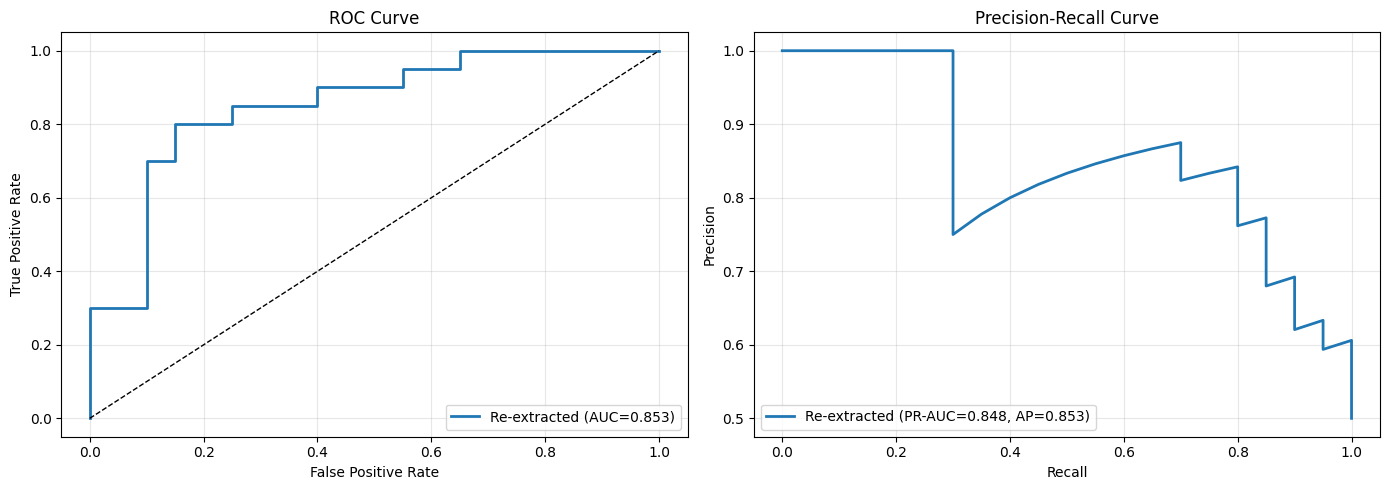

In [48]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    auc,
    average_precision_score,
)

# Combined evaluation set built from our sampled TN and TP runs
_tn_path = Path("data/top20_true_negatives_reextracted_seed42.json")
_tp_path = Path("data/top20_true_positives_reextracted_seed42.json")

_tn_rows = json.loads(_tn_path.read_text(encoding="utf-8"))
_tp_rows = json.loads(_tp_path.read_text(encoding="utf-8"))
_rows = _tn_rows + _tp_rows

_y_true = []
_s_current = []

for _r in _rows:
    _curr = _r.get("contradiction_percent")
    _y = _r.get("y_true")

    # Keep only complete rows for curve calculation
    if _curr is None or _y is None:
        continue

    _y_true.append(int(float(_y)))
    _s_current.append(float(_curr) / 100.0)

_y_true = np.array(_y_true, dtype=int)
_s_current = np.array(_s_current, dtype=float)

if len(_y_true) == 0:
    raise ValueError("No valid rows found to compute ROC/PR curves.")

# ROC
_fpr_c, _tpr_c, _ = roc_curve(_y_true, _s_current)
_roc_auc_c = roc_auc_score(_y_true, _s_current)

# PR
_prec_c, _rec_c, _ = precision_recall_curve(_y_true, _s_current)
_pr_auc_c = auc(_rec_c, _prec_c)
_ap_c = average_precision_score(_y_true, _s_current)

print(f"Rows used: {len(_y_true)}")
print(f"Positives: {int((_y_true == 1).sum())}, Negatives: {int((_y_true == 0).sum())}")
print()
print("AUC summary (re-extracted only)")
print("=" * 60)
print(f"ROC-AUC re-extracted      : {_roc_auc_c:.4f}")
print(f"PR-AUC  re-extracted      : {_pr_auc_c:.4f}")
print(f"Avg Precision re-extracted: {_ap_c:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
axes[0].plot(_fpr_c, _tpr_c, label=f"Re-extracted (AUC={_roc_auc_c:.3f})", linewidth=2)
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# PR curve
axes[1].plot(_rec_c, _prec_c, label=f"Re-extracted (PR-AUC={_pr_auc_c:.3f}, AP={_ap_c:.3f})", linewidth=2)
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="lower left")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()